We decided to work with CIFAR-10 for the Project.
1. load data
- Load training and test sets
- Verify shapes
- Verify data types
- Verify labels
2. EDA:
  - print dataset shape & pixel range
  - print classes (class imbalance)
  - check for duplicates
  - check for blanks
  - Visualization:
    - random (32 images)
    - random images per class
3. Data Preprocessing
  - Normalizing values
  - One-hot encoding (to_categorical())
  - Split the data
    Training set
    Validation set
    Test set
    Use stratification if appropriate ?
  - Data augmentation
    Examples:
    Horizontal flip
    Small rotations
    Zoom
    Width/height shifts
    (Apply only to the training set.)
 4. Build a CNN from Transfer Learning with VGG16

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
import numpy as np

In [67]:
x_temp = np.load('/content/drive/MyDrive/cifar10_data/x_train.npy')
y_temp = np.load('/content/drive/MyDrive/cifar10_data/y_train.npy')
x_test = np.load('/content/drive/MyDrive/cifar10_data/x_test.npy')
y_test = np.load('/content/drive/MyDrive/cifar10_data/y_test.npy')

In [68]:
print(x_temp.min(), x_temp.max())

0.0 1.0


In [69]:
import tensorflow as tf

x_temp = tf.image.resize(x_temp, [32, 32]).numpy()
x_test  = tf.image.resize(x_test,  [32, 32]).numpy()

np.save('/content/drive/MyDrive/cifar10_data/x_train.npy', x_temp)
np.save('/content/drive/MyDrive/cifar10_data/x_test.npy',  x_test)

print("Done! Shapes:")
print("x_train:", x_temp.shape)
print("x_test: ", x_test.shape)

Done! Shapes:
x_train: (50000, 32, 32, 3)
x_test:  (10000, 32, 32, 3)


In [70]:
print("x_temp:", x_temp.shape)
print("y_temp:", y_temp.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

x_temp: (50000, 32, 32, 3)
y_temp: (50000, 10)
x_test : (10000, 32, 32, 3)
y_test : (10000, 10)


In [71]:
import numpy as np

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
labels, counts = np.unique(np.argmax(y_temp, axis=1), return_counts=True)

for l, c in zip(labels, counts):
    print(f"{classes[int(l)]}: {c}")

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


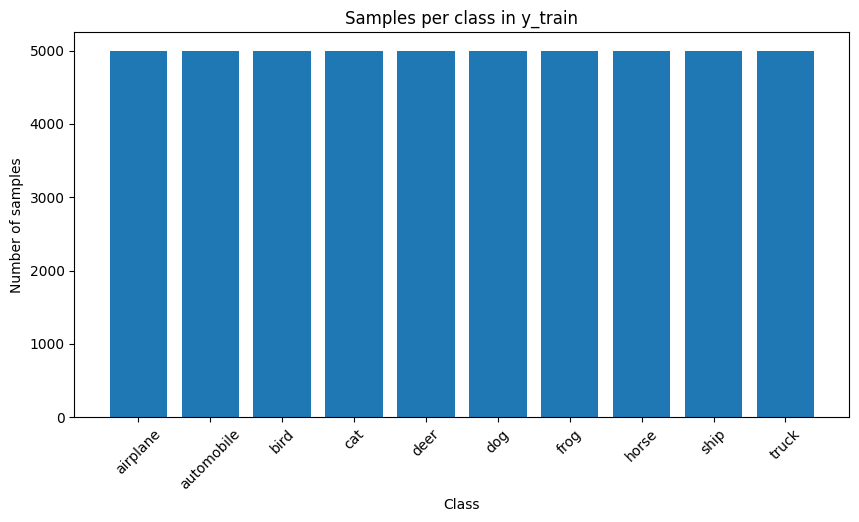

In [72]:
import matplotlib.pyplot as plt

labels, counts = np.unique(np.argmax(y_temp, axis=1), return_counts=True)

plt.figure(figsize=(10,5))
plt.bar([classes[int(l)] for l in labels], counts)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Samples per class in y_train")
plt.xticks(rotation=45)
plt.show()

In [73]:
# Basic info & pixel range
print("=== Dataset shapes ===")
print(f"x_temp: {x_temp.shape}")
print(f"y_temp: {y_temp.shape}")
print(f"x_test:  {x_test.shape}")
print(f"y_test:  {y_test.shape}")

print("\n=== Pixel values ===")
print(f"Min: {x_temp.min()}")
print(f"Max: {x_temp.max()}")
print(f"Mean: {x_temp.mean():.4f}")

=== Dataset shapes ===
x_temp: (50000, 32, 32, 3)
y_temp: (50000, 10)
x_test:  (10000, 32, 32, 3)
y_test:  (10000, 10)

=== Pixel values ===
Min: 0.0
Max: 1.0
Mean: 0.4734


In [74]:
# Duplicates?

# x_flat = x_temp.reshape(len(x_temp), -1)
# unique = np.unique(x_flat, axis=0)
# print(f"Total images:  {len(x_temp)}")
# print(f"Unique images: {len(unique)}")
# print(f"Duplicates:    {len(x_temp) - len(unique)}")


In [75]:
# blank images? if all pixels same value -> is blank

# blank = [i for i in range(len(x_temp)) if x_temp[i].std() == 0]
# print(f"Blank/corrupt images: {len(blank)}")

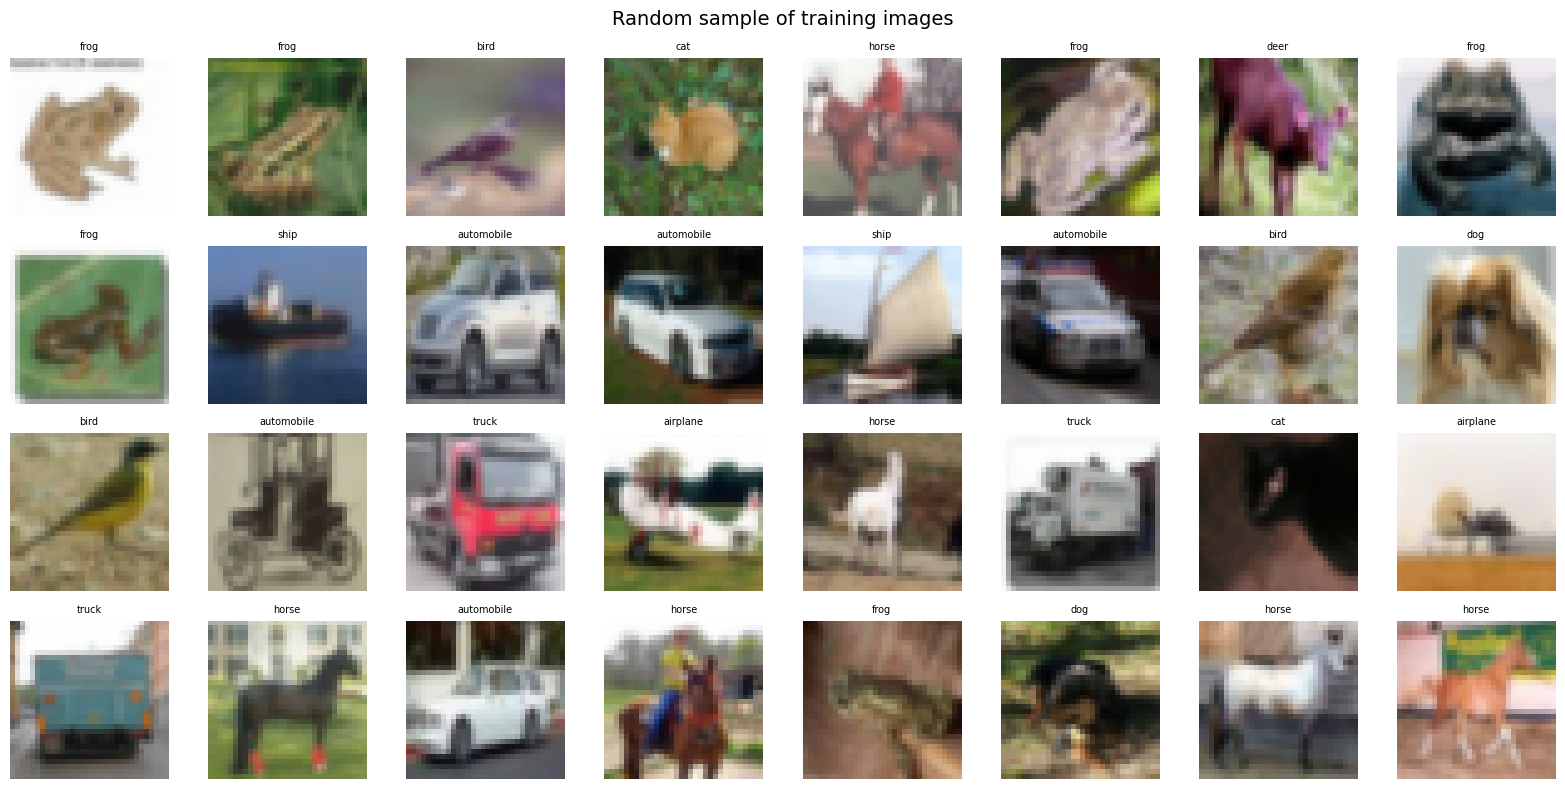

In [76]:
# random plot of images

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

random_indices = np.random.choice(len(x_temp), 32, replace=False)

for i, idx in enumerate(random_indices):
    axes[i].imshow(x_temp[idx])
    axes[i].set_title(classes[np.argmax(y_temp[idx])], fontsize=7)
    axes[i].axis('off')

plt.suptitle('Random sample of training images', fontsize=14)
plt.tight_layout()
plt.show()

In [77]:
print(y_temp.shape)
print(y_temp[0])

(50000, 10)
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


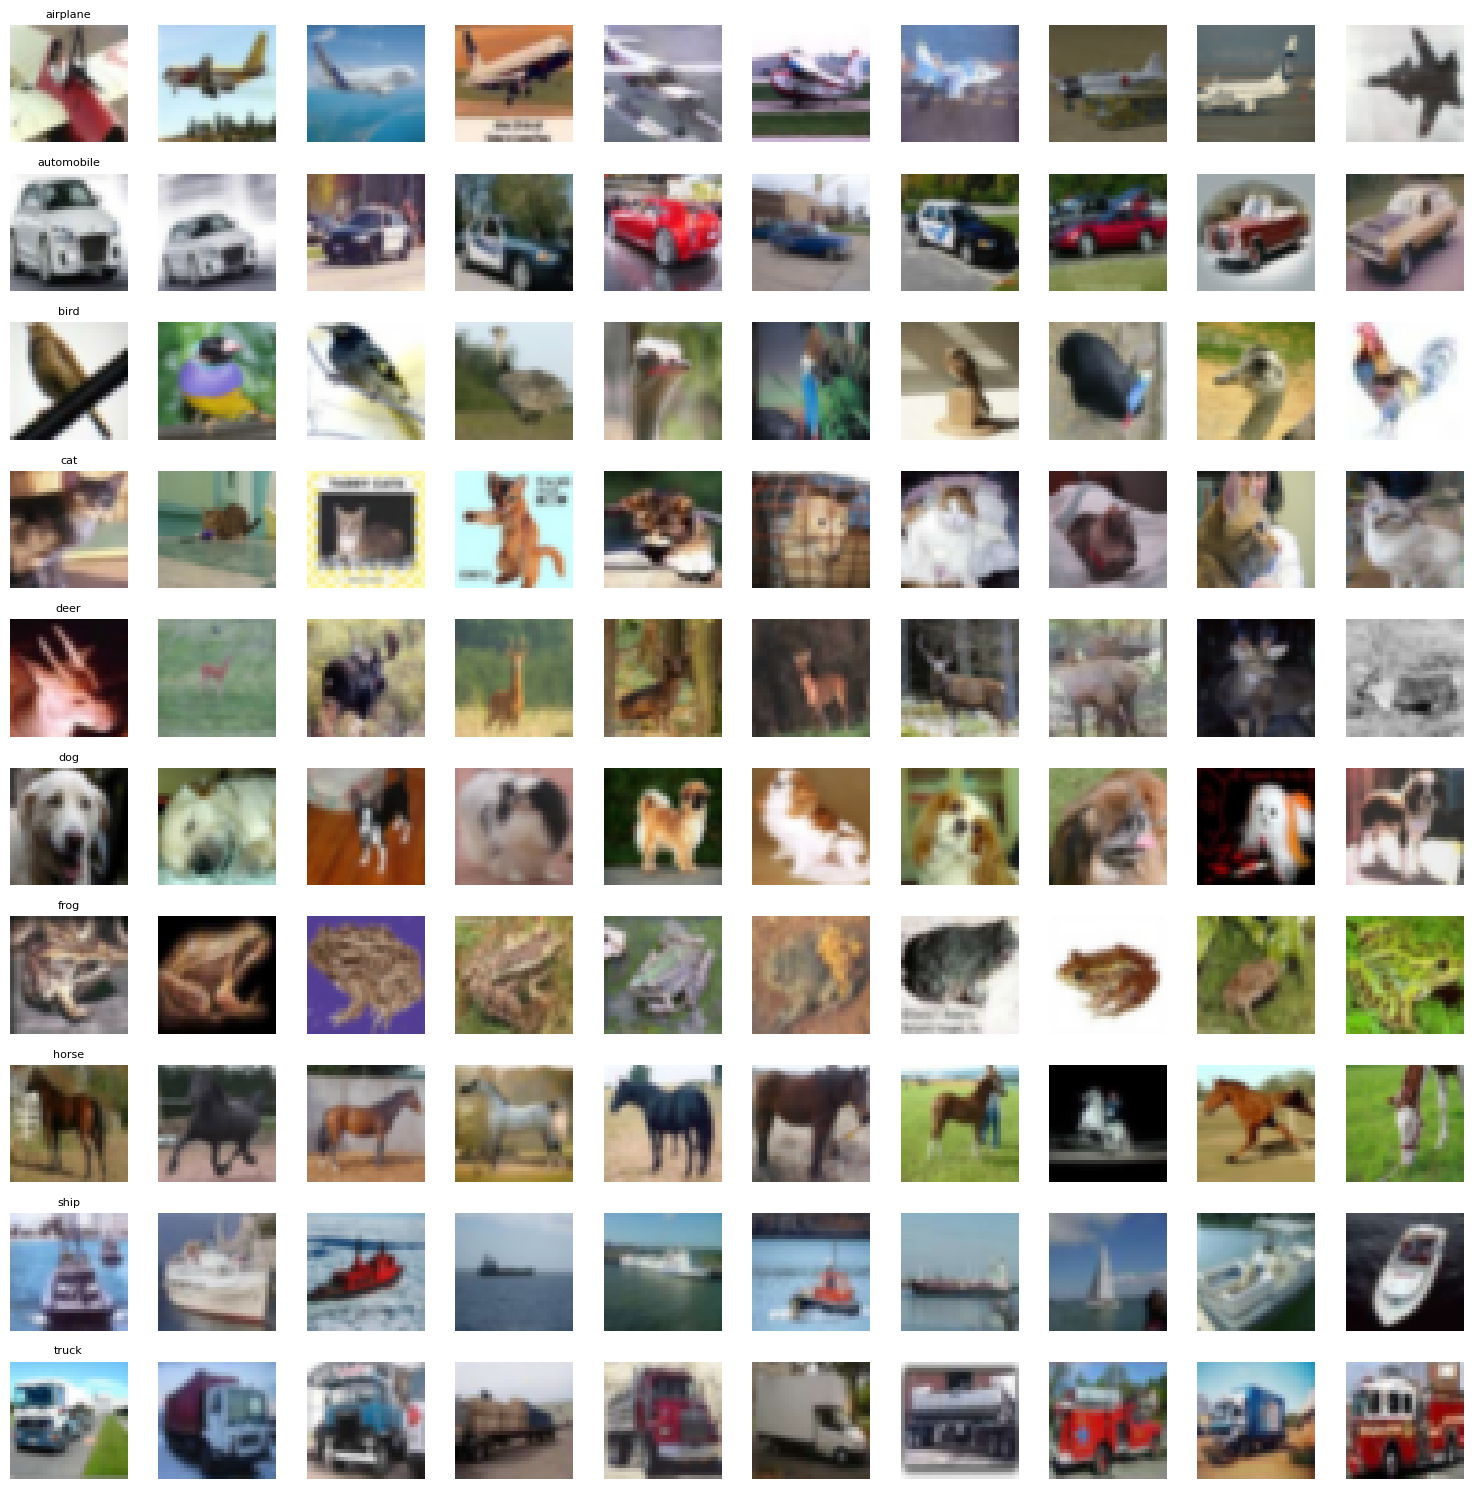

In [78]:
# Visualise samples/class

fig, axes = plt.subplots(10, 10, figsize=(15, 15))

y_temp_labels = np.argmax(y_temp, axis=1)  # recover integer labels

for class_idx in range(10):
    class_indices = np.where(y_temp_labels == class_idx)[0]
    sample_indices = np.random.choice(class_indices, 10, replace=False)
    for col, img_idx in enumerate(sample_indices):
        axes[class_idx, col].imshow(x_temp[img_idx])
        axes[class_idx, col].axis('off')
        if col == 0:
            axes[class_idx, col].set_title(classes[class_idx], fontsize=8)

plt.tight_layout()
plt.show()

In [79]:
from sklearn.model_selection import train_test_split

# x_train, y_train from CIFAR-10's original train set
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.18,
    stratify=y_temp.argmax(axis=1),    # keep class balance
    random_state=42
)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val  :", x_val.shape)
print("y_val  :", y_val.shape)

x_train: (41000, 32, 32, 3)
y_train: (41000, 10)
x_val  : (9000, 32, 32, 3)
y_val  : (9000, 10)


In [103]:
from tensorflow.keras.utils import to_categorical


x_train = x_train.astype('float32') * 255.0
x_test  = x_test.astype('float32') * 255.0

x_val = x_val.astype('float32') * 255.0
# y_val = to_categorical(y_val, num_classes=10)

# y_train = to_categorical(y_train, num_classes=10)
# y_test  = to_categorical(y_test, num_classes=10)

print("x_train shape:", x_train.shape)
# print("y_train shape:", y_train.shape)
print("x_test shape: ", x_test.shape)
# print("y_test shape: ", y_test.shape)
print("x_val shape:  ", x_val.shape)
# print("y_val shape:  ", y_val.shape)

x_train shape: (41000, 32, 32, 3)
x_test shape:  (10000, 32, 32, 3)
x_val shape:   (9000, 32, 32, 3)


In [104]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model

In [105]:
IMG_SIZE = 224

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))

In [106]:
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .map(
        lambda x, y: (
            preprocess_input(tf.image.resize(x, (IMG_SIZE, IMG_SIZE))),
            y
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .map(
        lambda x, y: (
            preprocess_input(tf.image.resize(x, (IMG_SIZE, IMG_SIZE))),
            y
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .map(
        lambda x, y: (
            preprocess_input(tf.image.resize(x, (IMG_SIZE, IMG_SIZE))),
            y
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [107]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [108]:
base_model.trainable = False

In [109]:
inputs = Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

outputs = Dense(10, activation='softmax')(x)

model_vgg = Model(inputs, outputs)

In [110]:
model_vgg.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [111]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, earlystop, reduce_lr]

In [114]:
from tensorflow.keras.optimizers import Adam

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.3690 - loss: 2.3922
Epoch 1: val_accuracy improved from None to 0.73356, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 305s 234ms/step - accuracy: 0.5063 - loss: 1.5876 - val_accuracy: 0.7336 - val_loss: 0.7917 - learning_rate: 1.0000e-04
Epoch 2/20
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6670 - loss: 0.9687
Epoch 2: val_accuracy improved from 0.73356 to 0.77544, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 295s 230ms/step - accuracy: 0.6893 - loss: 0.9062 - val_accuracy: 0.7754 - val_loss: 0.6596 - learning_rate: 1.0000e-04
Epoch 3/20
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7295 - loss: 0.7917
Epoch 3: val_accuracy improved from 0.77544 to 0.79344, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1282/128

In [115]:
loss, accuracy = model_vgg.evaluate(test_ds)

print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 196ms/step - accuracy: 0.8390 - loss: 0.4769
Test Accuracy: 0.8390


In [117]:
history_vgg.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [118]:
print(history_vgg.history["accuracy"][-1])
print(history_vgg.history["val_accuracy"][-1])

0.865756094455719
0.8412222266197205


In [119]:
import numpy as np

y_pred_prob = model_vgg.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 195ms/step


In [120]:
y_true = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

In [121]:
import numpy as np

print(np.unique(y_pred))
print(np.bincount(y_pred))

[0 1 2 3 4 5 6 7 8 9]
[ 977  978  913 1012 1066  982 1057  957 1046 1012]


In [122]:
pred = model_vgg.predict(test_ds)

print(pred.shape)
print(pred[0])
print(np.argmax(pred[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 193ms/step
(10000, 10)
[1.8309731e-02 4.6177146e-01 7.9693254e-03 1.7173880e-01 4.4519457e-04
 1.7602405e-02 2.8409082e-01 1.1336562e-04 1.5663689e-02 2.2295244e-02]
1


In [96]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

In [126]:
predictions = model_vgg.predict(test_ds)

print(predictions.shape)
print(predictions[0])
print(np.argmax(predictions[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 194ms/step
(10000, 10)
[1.8309731e-02 4.6177146e-01 7.9693254e-03 1.7173880e-01 4.4519457e-04
 1.7602405e-02 2.8409082e-01 1.1336562e-04 1.5663689e-02 2.2295244e-02]
1


In [127]:
import numpy as np

y_pred = np.argmax(predictions, axis=1)

unique, counts = np.unique(y_pred, return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(0): np.int64(977), np.int64(1): np.int64(978), np.int64(2): np.int64(913), np.int64(3): np.int64(1012), np.int64(4): np.int64(1066), np.int64(5): np.int64(982), np.int64(6): np.int64(1057), np.int64(7): np.int64(957), np.int64(8): np.int64(1046), np.int64(9): np.int64(1012)}


In [128]:
model_vgg.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,116,384 (57.66 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 267,798 (1.02 MB)

In [129]:
loss, acc = model_vgg.evaluate(test_ds)

print(acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 194ms/step - accuracy: 0.8390 - loss: 0.4769
0.8389999866485596


In [131]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict on the test dataset
predictions = model_vgg.predict(test_ds)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# Convert one-hot encoded labels to integers
y_true = np.argmax(y_test, axis=1)

# Build a NEW confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 188ms/step
[[849  13  24  18  11   2   2   7  61  13]
 [ 11 889   2   5   2   3   2   2  19  65]
 [ 27   2 760  42  63  22  58  18   7   1]
 [ 10   5  30 730  42 110  37  15  11  10]
 [ 11   1  33  27 830  15  40  33   7   3]
 [  3   0  18 130  31 771  19  25   1   2]
 [  3   4  25  36  24  14 887   4   2   1]
 [ 11   2  12  16  58  40   5 850   3   3]
 [ 37  10   6   5   4   1   4   1 921  11]
 [ 15  52   3   3   1   4   3   2  14 903]]


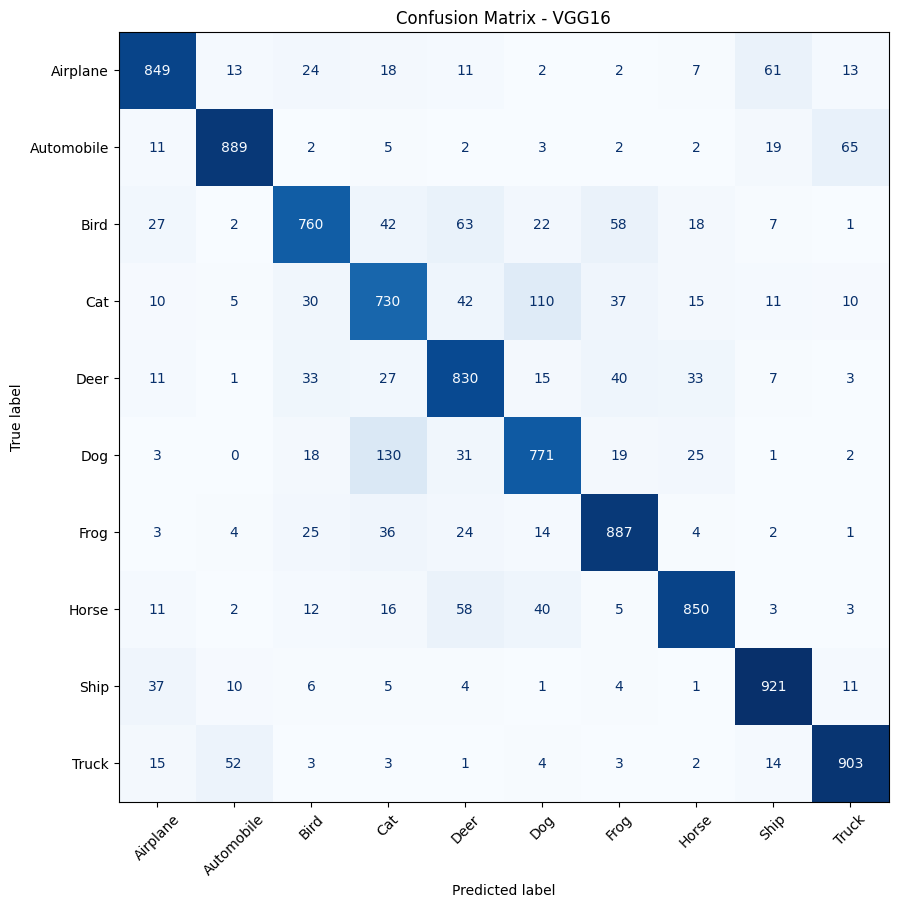

In [132]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

fig, ax = plt.subplots(figsize=(10,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)

plt.title("Confusion Matrix - VGG16")
plt.show()

In [133]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.87      0.85      0.86      1000
  Automobile       0.91      0.89      0.90      1000
        Bird       0.83      0.76      0.79      1000
         Cat       0.72      0.73      0.73      1000
        Deer       0.78      0.83      0.80      1000
         Dog       0.79      0.77      0.78      1000
        Frog       0.84      0.89      0.86      1000
       Horse       0.89      0.85      0.87      1000
        Ship       0.88      0.92      0.90      1000
       Truck       0.89      0.90      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



In [134]:
import os

save_path = "/content/drive/MyDrive/CNN_Models"
os.makedirs(save_path, exist_ok=True)

model_vgg.save(os.path.join(save_path, "Model_FM_VGG16.keras"))